# 1. Introduction

The `xai_brain_ct` notebook uses a patient-level train and test split to evaluate the ICH classification model.

However, patients contain different numbers of CT slices, and ICH patients may also contain different numbers and types of hemorrhagic slices. Therefore, a patient-level split may still result in unbalanced distributions across the subsets.

This notebook explores these patient-level characteristics to design a more representative **static train and test split** for the experiments in `xai_brain_ct`.

# 2. Dataset Overview

We first examine the overall composition of the dataset at both the patient and slice levels.

In [94]:
from pathlib import Path

from src.data_loading import load_demographics, load_diagnosis

data_dir = Path("data")

diagnosis_df = load_diagnosis(data_dir)
demographics_df = load_demographics(data_dir)

print("Diagnosis shape:", diagnosis_df.shape)
print("Demographics shape:", demographics_df.shape)

Diagnosis shape: (2501, 9)
Demographics shape: (82, 11)


In [95]:
print("Columns:")
for column in diagnosis_df.columns:
    print(f"  - {column}")

print()
print("First 5 slice records")
display(diagnosis_df.head())

Columns:
  - PatientNumber
  - SliceNumber
  - Intraventricular
  - Intraparenchymal
  - Subarachnoid
  - Epidural
  - Subdural
  - No_Hemorrhage
  - Fracture_Yes_No

First 5 slice records


,PatientNumber,SliceNumber,Intraventricular,Intraparenchymal,Subarachnoid,Epidural,Subdural,No_Hemorrhage,Fracture_Yes_No
0,49,1,0,0,0,0,0,1,0
1,49,2,0,0,0,0,0,1,0
2,49,3,0,0,0,0,0,1,0
3,49,4,0,0,0,0,0,1,0
4,49,5,0,0,0,0,0,1,0


# 3. Patient-Level Slice Distribution
We examine how the number of CT slices varies across patients.

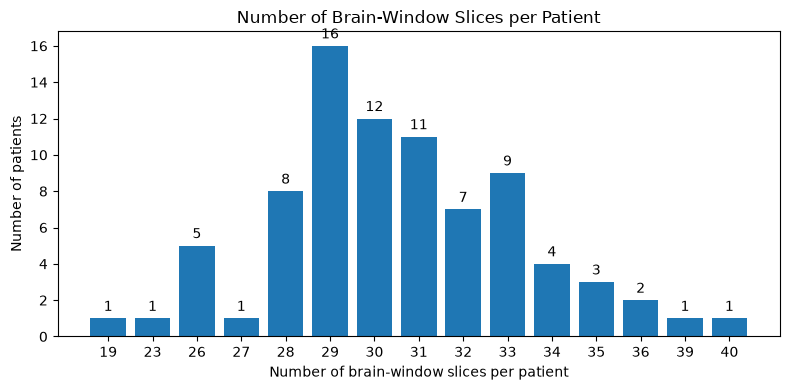

In [96]:
import matplotlib.pyplot as plt

slice_counts = (
    diagnosis_df
    .groupby("PatientNumber")
    .size()
    .reset_index(name="Total_Slices")
)

slice_distribution = (
    slice_counts["Total_Slices"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))

bars = plt.bar(
    slice_distribution.index.astype(str),
    slice_distribution.values,
    width=0.8,
)

plt.xlabel("Number of brain-window slices per patient")
plt.ylabel("Number of patients")
plt.title("Number of Brain-Window Slices per Patient")

plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

# 4. ICH Slice Distribution

We now examine how ICH slices are distributed across patients. For each patient, we consider the total number of ICH slices and, for ICH patients, the proportion of slices containing hemorrhage.


In [97]:
ich_slice_counts = (
    diagnosis_df[diagnosis_df["No_Hemorrhage"] == 0]
    .groupby("PatientNumber")
    .size()
    .reset_index(name="ICH_Slices")
)

patient_slice_summary = slice_counts.merge(
    ich_slice_counts,
    on="PatientNumber",
    how="left",
)

patient_slice_summary["ICH_Slices"] = (
    patient_slice_summary["ICH_Slices"]
    .fillna(0)
    .astype(int)
)

patient_slice_summary["Non_ICH_Slices"] = (
    patient_slice_summary["Total_Slices"]
    - patient_slice_summary["ICH_Slices"]
)

patient_slice_summary["ICH_Ratio"] = (
    patient_slice_summary["ICH_Slices"]
    / patient_slice_summary["Total_Slices"]
)

display(patient_slice_summary.head())

,PatientNumber,Total_Slices,ICH_Slices,Non_ICH_Slices,ICH_Ratio
0,49,33,9,24,0.272727
1,50,26,12,14,0.461538
2,51,32,19,13,0.593750
3,52,30,9,21,0.300000
4,53,33,10,23,0.303030


In [98]:
ich_patients = patient_slice_summary[
    patient_slice_summary["ICH_Slices"] > 0
].copy()

print("ICH slices per patient\n")

print(f"Number of ICH patients: {len(ich_patients)}")
print(f"Minimum ICH slices:     {ich_patients['ICH_Slices'].min()}")
print(f"Maximum ICH slices:     {ich_patients['ICH_Slices'].max()}")
print(f"Mean ICH slices:        {ich_patients['ICH_Slices'].mean():.1f}")
print(f"Median ICH slices:      {ich_patients['ICH_Slices'].median():.1f}")

ICH slices per patient

Number of ICH patients: 36
Minimum ICH slices:     1
Maximum ICH slices:     19
Mean ICH slices:        8.8
Median ICH slices:      9.0


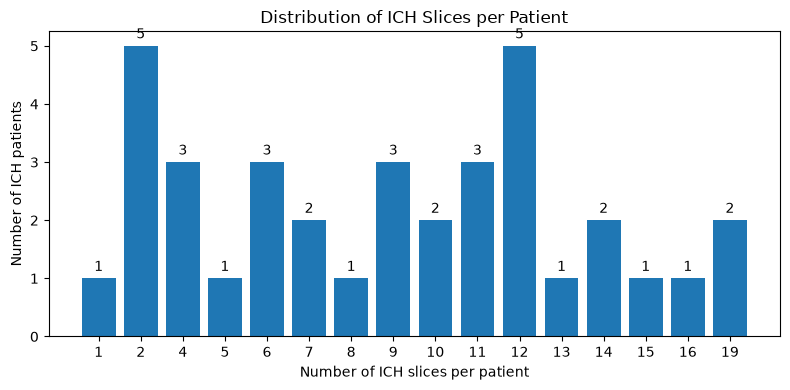

In [99]:
ich_distribution = (
    ich_patients["ICH_Slices"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))

bars = plt.bar(
    ich_distribution.index.astype(str),
    ich_distribution.values,
)

plt.xlabel("Number of ICH slices per patient")
plt.ylabel("Number of ICH patients")
plt.title("Distribution of ICH Slices per Patient")

plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

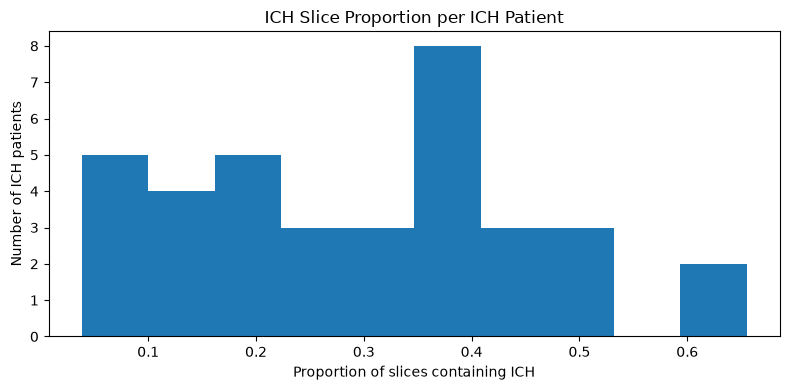

In [100]:
plt.figure(figsize=(8, 4))

plt.hist(
    ich_patients["ICH_Ratio"],
    bins=10,
)

plt.xlabel("Proportion of slices containing ICH")
plt.ylabel("Number of ICH patients")
plt.title("ICH Slice Proportion per ICH Patient")

plt.tight_layout()
plt.show()

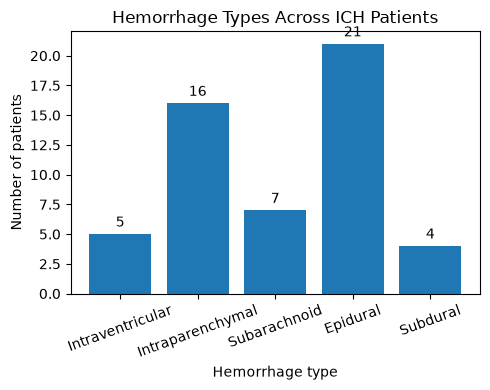

In [101]:
import pandas as pd

hemorrhage_types = [
    "Intraventricular",
    "Intraparenchymal",
    "Subarachnoid",
    "Epidural",
    "Subdural",
]

type_patient_counts = {
    hemorrhage_type: diagnosis_df.loc[
        diagnosis_df[hemorrhage_type] == 1,
        "PatientNumber"
    ].nunique()
    for hemorrhage_type in hemorrhage_types
}

type_patient_counts = pd.Series(type_patient_counts)

plt.figure(figsize=(5, 4))

bars = plt.bar(
    type_patient_counts.index,
    type_patient_counts.values,
)

plt.xlabel("Hemorrhage type")
plt.ylabel("Number of patients")
plt.title("Hemorrhage Types Across ICH Patients")

plt.xticks(rotation=20)
plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

# 5. Patient-Level Summary

We combine the previously explored characteristics into a single patient-level summary.

This table includes the total number of CT slices, the number and proportion of ICH slices, and the hemorrhage types present for each patient. It will be used to assess and construct a representative patient-level split.

In [102]:
patient_summary = patient_slice_summary.copy()

# Add patient-level ICH label
patient_summary["ICH"] = (
    patient_summary["ICH_Slices"] > 0
).astype(int)

# Add hemorrhage types present for each patient
def get_hemorrhage_types(row):
    return [
        hemorrhage_type
        for hemorrhage_type in hemorrhage_types
        if row[hemorrhage_type] == 1
    ]


patient_types = (
    diagnosis_df
    .groupby("PatientNumber")[hemorrhage_types]
    .max()
    .reset_index()
)

patient_summary = patient_summary.merge(
    patient_types,
    on="PatientNumber",
    how="left",
)

patient_summary["Hemorrhage_Types"] = patient_summary.apply(
    get_hemorrhage_types,
    axis=1,
)

patient_summary = patient_summary[
    [
        "PatientNumber",
        "ICH",
        "Total_Slices",
        "ICH_Slices",
        "Non_ICH_Slices",
        "ICH_Ratio",
        "Hemorrhage_Types",
    ]
]

display(patient_summary.head())

,PatientNumber,ICH,Total_Slices,ICH_Slices,Non_ICH_Slices,ICH_Ratio,Hemorrhage_Types
0,49,1,33,9,24,0.272727,"[Intraparenchymal, Epidural]"
1,50,1,26,12,14,0.461538,[Intraparenchymal]
2,51,1,32,19,13,0.593750,"[Intraparenchymal, Subdural]"
3,52,1,30,9,21,0.300000,[Epidural]
4,53,1,33,10,23,0.303030,"[Intraparenchymal, Epidural]"


# 6. Dataset-Level Summary

We summarize the main patient-level characteristics of the complete dataset.

These values provide reference points for constructing a representative static train, validation, and test split.

In [103]:
total_patients = len(patient_summary)
ich_patients_count = patient_summary["ICH"].sum()
non_ich_patients_count = total_patients - ich_patients_count

total_slices = patient_summary["Total_Slices"].sum()
total_ich_slices = patient_summary["ICH_Slices"].sum()
total_non_ich_slices = patient_summary["Non_ICH_Slices"].sum()

print(f"Total patients:        {total_patients}")
print(f"ICH patients:          {ich_patients_count}")
print(f"Non-ICH patients:      {non_ich_patients_count}")
print()
print(f"Total CT slices:       {total_slices}")
print(f"ICH slices:            {total_ich_slices}")
print(f"Non-ICH slices:        {total_non_ich_slices}")
print()
print(
    f"ICH slice proportion:  "
    f"{total_ich_slices / total_slices:.3f}"
)

Total patients:        82
ICH patients:          36
Non-ICH patients:      46

Total CT slices:       2501
ICH slices:            318
Non-ICH slices:        2183

ICH slice proportion:  0.127


# 7. Stratification Design

## 7.1 Patient-Level Strata

We define patient-level strata using characteristics that may affect the distribution of the data across splits.

Each patient is characterized by:
- ICH status
- Hemorrhage type set
- ICH slice burden
- Total number of CT slices

These characteristics are combined into patient-level strata to examine how finely the dataset can be stratified and whether direct stratified allocation is practical.

In [104]:
# Create a copy so the original patient summary remains unchanged.
stratification_df = patient_summary.copy()


# 1. ICH status
stratification_df["ICH_Status"] = stratification_df["ICH"].map(
    {0: "Non-ICH", 1: "ICH"}
)


# 2. Hemorrhage type set
# Sort the types so that the same combination always has the same representation.
def format_hemorrhage_types(types):
    if not types:
        return "None"
    
    return "+".join(sorted(types))


stratification_df["Hemorrhage_Type_Set"] = (
    stratification_df["Hemorrhage_Types"]
    .apply(format_hemorrhage_types)
)


# 3. ICH slice-burden bucket
# Only ICH patients have an ICH burden.
stratification_df["ICH_Burden_Bucket"] = "None"

ich_mask = stratification_df["ICH"] == 1

stratification_df.loc[ich_mask, "ICH_Burden_Bucket"] = pd.qcut(
    stratification_df.loc[ich_mask, "ICH_Ratio"],
    q=3,
    labels=["Low", "Medium", "High"],
)


# 4. Total slice-count bucket
stratification_df["Slice_Count_Bucket"] = pd.qcut(
    stratification_df["Total_Slices"],
    q=3,
    labels=["Low", "Medium", "High"],
)


# 5. Combined patient-level stratum
stratification_df["Stratum"] = (
    stratification_df["ICH_Status"]
    + " | "
    + stratification_df["Hemorrhage_Type_Set"]
    + " | "
    + stratification_df["ICH_Burden_Bucket"].astype(str)
    + " | "
    + stratification_df["Slice_Count_Bucket"].astype(str)
)


stratification_df[
    [
        "PatientNumber",
        "ICH_Status",
        "Hemorrhage_Type_Set",
        "ICH_Ratio",
        "ICH_Burden_Bucket",
        "Total_Slices",
        "Slice_Count_Bucket",
        "Stratum",
    ]
].head(10)

,PatientNumber,ICH_Status,Hemorrhage_Type_Set,ICH_Ratio,ICH_Burden_Bucket,Total_Slices,Slice_Count_Bucket,Stratum
0,49,ICH,Epidural+Intraparenchymal,0.272727,Medium,33,High,ICH | Epidural+Intraparenchymal | Medium | High
1,50,ICH,Intraparenchymal,0.461538,High,26,Low,ICH | Intraparenchymal | High | Low
2,51,ICH,Intraparenchymal+Subdural,0.593750,High,32,High,ICH | Intraparenchymal+Subdural | High | High
3,52,ICH,Epidural,0.300000,Medium,30,Medium,ICH | Epidural | Medium | Medium
4,53,ICH,Epidural+Intraparenchymal,0.303030,Medium,33,High,ICH | Epidural+Intraparenchymal | Medium | High
5,54,Non-ICH,None,0.000000,None,28,Low,Non-ICH | None | None | Low
6,55,Non-ICH,None,0.000000,None,32,High,Non-ICH | None | None | High
7,56,Non-ICH,None,0.000000,None,33,High,Non-ICH | None | None | High
8,57,Non-ICH,None,0.000000,None,35,High,Non-ICH | None | None | High
9,58,ICH,Intraparenchymal,0.058824,Low,34,High,ICH | Intraparenchymal | Low | High


## 7.2 Stratum Sizes

We examine the number of patients in each stratum.

Large strata can be distributed proportionally across the splits, while very small strata may require special handling because they cannot be represented in every split.

In [105]:
stratum_sizes = (
    stratification_df["Stratum"]
    .value_counts()
    .rename_axis("Stratum")
    .reset_index(name="Patients")
)

stratum_sizes

,Stratum,Patients
0,Non-ICH | None | None | Low,19
1,Non-ICH | None | None | Medium,16
2,Non-ICH | None | None | High,11
3,ICH | Epidural | Medium | Medium,3
4,ICH | Epidural+Intraparenchymal | Medium | High,2
5,ICH | Intraparenchymal | Low | High,2
6,ICH | Epidural | High | Low,2
7,ICH | Epidural | Low | Low,2
8,ICH | Epidural | High | High,2
9,ICH | Epidural | Low | High,2


In [106]:
rare_strata = stratum_sizes[
    stratum_sizes["Patients"] <= 2
].copy()

print(f"Number of rare strata: {len(rare_strata)}")
print()

rare_strata

Number of rare strata: 26



,Stratum,Patients
4,ICH | Epidural+Intraparenchymal | Medium | High,2
5,ICH | Intraparenchymal | Low | High,2
6,ICH | Epidural | High | Low,2
7,ICH | Epidural | Low | Low,2
8,ICH | Epidural | High | High,2
9,ICH | Epidural | Low | High,2
10,ICH | Epidural | Medium | High,2
11,ICH | Intraparenchymal | High | Low,1
12,ICH | Intraparenchymal+Subdural | High | High,1
13,ICH | Intraparenchymal+Subdural | High | Low,1


In [107]:
print("Stratum size distribution:")
print(
    stratum_sizes["Patients"]
    .value_counts()
    .sort_index()
)

Stratum size distribution:
Patients
1     19
2      7
3      1
11     1
16     1
19     1
Name: count, dtype: int64


# 8. Constrained Split Construction

## 8.1 Constraint Feasibility

### 8.1.1 IndividualFeasibility
Before constructing the split, we first verify that each hemorrhage type has enough patients to satisfy the required test and development coverage.

For each hemorrhage type with at least 3 patients, we require at least one patient in the test set and at least two patients in the development set.

This check is performed before optimization so that the split construction does not rely on an infeasible set of constraints.

In [108]:
# Required coverage for each hemorrhage type
MIN_TEST_PER_TYPE = 1
MIN_DEV_PER_TYPE = 2

type_feasibility = []

for hemorrhage_type in hemorrhage_types:
    patient_ids = patient_summary.loc[
        patient_summary["Hemorrhage_Types"].apply(
            lambda types: hemorrhage_type in types
        ),
        "PatientNumber",
    ].tolist()

    total_patients = len(patient_ids)

    type_feasibility.append(
        {
            "Hemorrhage_Type": hemorrhage_type,
            "Total_Patients": total_patients,
            "Required_Test": MIN_TEST_PER_TYPE,
            "Required_Dev": MIN_DEV_PER_TYPE,
            "Feasible": (
                total_patients
                >= MIN_TEST_PER_TYPE + MIN_DEV_PER_TYPE
            ),
        }
    )

type_feasibility = pd.DataFrame(type_feasibility)

type_feasibility

,Hemorrhage_Type,Total_Patients,Required_Test,Required_Dev,Feasible
0,Intraventricular,5,1,2,True
1,Intraparenchymal,16,1,2,True
2,Subarachnoid,7,1,2,True
3,Epidural,21,1,2,True
4,Subdural,4,1,2,True


In [109]:
if type_feasibility["Feasible"].all():
    print("All hemorrhage-type coverage constraints are individually feasible.")
else:
    print("At least one hemorrhage type has insufficient patients.")
    display(
        type_feasibility[
            ~type_feasibility["Feasible"]
        ]
    )

All hemorrhage-type coverage constraints are individually feasible.


### 8.1.2 Joint Feasibility

Individual feasibility does not guarantee that all hemorrhage-type constraints can be satisfied simultaneously because a single patient may have multiple hemorrhage types.

We therefore check whether there exists at least one 17-patient test set that satisfies all hard constraints at the same time.

In [110]:
import numpy as np
from scipy.optimize import milp, LinearConstraint, Bounds

# Binary variable for each patient:
# x_i = 1 if patient i is assigned to the test set, 0 otherwise.

patients = patient_summary["PatientNumber"].to_numpy()
n_patients = len(patients)

constraints = []
lower_bounds = []
upper_bounds = []

# 1. Exactly 17 patients in test
constraints.append(np.ones(n_patients))
lower_bounds.append(17)
upper_bounds.append(17)

# 2. Test set contains 6–9 ICH patients
ich_indicator = patient_summary["ICH"].to_numpy()
constraints.append(ich_indicator)
lower_bounds.append(6)
upper_bounds.append(9)

# 3. Hemorrhage-type coverage constraints
# For each type:
#   test_count >= 1
#   dev_count >= 2
# Since dev is the complement of test:
#   test_count <= total_type_patients - 2
for hemorrhage_type in hemorrhage_types:
    type_indicator = patient_summary["Hemorrhage_Types"].apply(
        lambda types: hemorrhage_type in types
    ).to_numpy()

    total_type_patients = type_indicator.sum()

    # At least 1 patient with this type in test
    constraints.append(type_indicator)
    lower_bounds.append(1)
    upper_bounds.append(total_type_patients - MIN_DEV_PER_TYPE)

A = np.vstack(constraints)

constraint = LinearConstraint(
    A,
    np.array(lower_bounds),
    np.array(upper_bounds),
)

# No optimization objective.
# We only want to know whether a feasible solution exists.
result = milp(
    c=np.zeros(n_patients),
    integrality=np.ones(n_patients),
    bounds=Bounds(
        np.zeros(n_patients),
        np.ones(n_patients),
    ),
    constraints=constraint,
)

if result.success:
    test_ids = patients[np.rint(result.x).astype(bool)]

    print("Joint constraints are feasible.")
    print(f"Found a valid test set with {len(test_ids)} patients:")
    print(sorted(test_ids.tolist()))
else:
    print("No jointly feasible test set was found.")
    print(result.message)

Joint constraints are feasible.
Found a valid test set with 17 patients:
[50, 58, 69, 72, 74, 79, 82, 90, 92, 123, 124, 125, 126, 127, 128, 129, 130]


## 8.2 Hard Constraints

The split must satisfy several patient-level constraints before slice-level characteristics are optimized.

- Each patient belongs to exactly one split.
- The test set contains 17 patients and the development set contains 65 patients.
- The test set contains 6–9 ICH patients, keeping the patient-level class distribution close to the full dataset.
- Hemorrhage types with at least 3 patients must be represented by at least one patient in test and at least two patients in development.
- Hemorrhage types with fewer than 3 patients are treated as rare cases and their placement is documented explicitly rather than forced into every split.

Slice-level characteristics are not treated as strict constraints at this stage. They will be used as optimization objectives when selecting among valid patient-level splits.

## 8.3 Constrained Candidate Selection

We now generate candidate test sets by randomly sampling patients and retaining only candidates that satisfy all hard constraints.

Among these valid candidates, we select the candidate that is most representative of the full dataset according to the predefined slice-level and patient-level objectives.
- ICH patient proportion
- ICH slice proportion
- total slices per patient
- ICH slices per ICH patient

The goal is not exact equality, but a reasonable approximation of the full dataset.

In [111]:
RANDOM_STATE = 42
N_CANDIDATES = 100_000

rng = np.random.default_rng(RANDOM_STATE)

patient_ids = patient_summary["PatientNumber"].to_numpy()

# Dataset-level reference values
TARGET_ICH_PATIENT_RATIO = patient_summary["ICH"].mean()

TARGET_ICH_SLICE_RATIO = (
    patient_summary["ICH_Slices"].sum()
    / patient_summary["Total_Slices"].sum()
)

TARGET_MEAN_SLICES = patient_summary["Total_Slices"].mean()

ich_patients = patient_summary[
    patient_summary["ICH"] == 1
]

TARGET_MEAN_ICH_SLICES = ich_patients["ICH_Slices"].mean()


def satisfies_hard_constraints(test_ids):
    """Check whether a candidate test set satisfies all hard constraints."""

    candidate = patient_summary[
        patient_summary["PatientNumber"].isin(test_ids)
    ]

    # Test size
    if len(candidate) != 17:
        return False

    # ICH patient count
    ich_count = candidate["ICH"].sum()

    if not 6 <= ich_count <= 9:
        return False

    # Hemorrhage-type coverage
    for hemorrhage_type in hemorrhage_types:
        test_count = candidate["Hemorrhage_Types"].apply(
            lambda types: hemorrhage_type in types
        ).sum()

        total_count = patient_summary["Hemorrhage_Types"].apply(
            lambda types: hemorrhage_type in types
        ).sum()

        dev_count = total_count - test_count

        if test_count < MIN_TEST_PER_TYPE:
            return False

        if dev_count < MIN_DEV_PER_TYPE:
            return False

    return True


def representativeness_score(test_ids):
    """Measure how closely a valid test set matches dataset-level targets."""

    candidate = patient_summary[
        patient_summary["PatientNumber"].isin(test_ids)
    ]

    ich_patient_ratio = candidate["ICH"].mean()

    ich_slice_ratio = (
        candidate["ICH_Slices"].sum()
        / candidate["Total_Slices"].sum()
    )

    mean_slices = candidate["Total_Slices"].mean()

    ich_patients = candidate[candidate["ICH"] == 1]

    mean_ich_slices = ich_patients["ICH_Slices"].mean()

    # Relative errors
    patient_error = (
    abs(ich_patient_ratio - TARGET_ICH_PATIENT_RATIO)
    / TARGET_ICH_PATIENT_RATIO
)

    slice_error = (
        abs(ich_slice_ratio - TARGET_ICH_SLICE_RATIO)
        / TARGET_ICH_SLICE_RATIO
    )

    slice_count_error = (
        abs(mean_slices - TARGET_MEAN_SLICES)
        / TARGET_MEAN_SLICES
    )

    ich_burden_error = (
        abs(mean_ich_slices - TARGET_MEAN_ICH_SLICES)
        / TARGET_MEAN_ICH_SLICES
    )

    # Equal weighting for the four objectives
    return (
        patient_error
        + slice_error
        + slice_count_error
        + ich_burden_error
    )


valid_candidates = []

for _ in range(N_CANDIDATES):
    test_ids = rng.choice(
        patient_ids,
        size=17,
        replace=False,
    )

    if satisfies_hard_constraints(test_ids):
        score = representativeness_score(test_ids)

        valid_candidates.append(
            (score, sorted(test_ids.tolist()))
        )

print(f"Valid candidates found: {len(valid_candidates)}")

valid_candidates.sort(key=lambda x: x[0])

if valid_candidates:
    best_score, best_test_ids = valid_candidates[0]

    print(f"Best candidate score: {best_score:.4f}")
    print("Best test patient IDs:")
    print(best_test_ids)
else:
    print("No valid candidates found.")

Valid candidates found: 26152
Best candidate score: 0.1244
Best test patient IDs:
[53, 57, 59, 61, 72, 74, 75, 83, 90, 92, 95, 98, 105, 112, 116, 124, 129]


## 8.4 Evaluate Candidate Split

We now evaluate the selected test set against the complete dataset and its corresponding development set.

The goal is to determine whether the candidate provides a sufficiently representative distribution of patient-level and slice-level characteristics while satisfying the hard constraints.

The selected candidate is accepted if the resulting distributions are sufficiently representative and all hard constraints are satisfied.

In [112]:
test_ids = best_test_ids

test_summary = patient_summary[
    patient_summary["PatientNumber"].isin(test_ids)
].copy()

dev_summary = patient_summary[
    ~patient_summary["PatientNumber"].isin(test_ids)
].copy()


def summarize_split(df):
    ich_patients = df[df["ICH"] == 1]

    return {
        "Patients": len(df),
        "ICH_Patients": int(df["ICH"].sum()),
        "ICH_Patient_Ratio": df["ICH"].mean(),
        "Total_Slices": int(df["Total_Slices"].sum()),
        "ICH_Slices": int(df["ICH_Slices"].sum()),
        "ICH_Slice_Ratio": (
            df["ICH_Slices"].sum()
            / df["Total_Slices"].sum()
        ),
        "Mean_Slices_Per_Patient": df["Total_Slices"].mean(),
        "Mean_ICH_Slices_Per_ICH_Patient": (
            ich_patients["ICH_Slices"].mean()
        ),
    }


split_comparison = pd.DataFrame(
    {
        "Full Dataset": summarize_split(patient_summary),
        "Test": summarize_split(test_summary),
        "Development": summarize_split(dev_summary),
    }
)

split_comparison

,Full Dataset,Test,Development
Patients,82.000000,17.000000,65.000000
ICH_Patients,36.000000,7.000000,29.000000
ICH_Patient_Ratio,0.439024,0.411765,0.446154
Total_Slices,2501.000000,518.000000,1983.000000
ICH_Slices,318.000000,62.000000,256.000000
ICH_Slice_Ratio,0.127149,0.119691,0.129097
Mean_Slices_Per_Patient,30.500000,30.470588,30.507692
Mean_ICH_Slices_Per_ICH_Patient,8.833333,8.857143,8.827586


In [113]:
type_coverage = []

for hemorrhage_type in hemorrhage_types:
    test_count = test_summary["Hemorrhage_Types"].apply(
        lambda types: hemorrhage_type in types
    ).sum()

    dev_count = dev_summary["Hemorrhage_Types"].apply(
        lambda types: hemorrhage_type in types
    ).sum()

    total_count = patient_summary["Hemorrhage_Types"].apply(
        lambda types: hemorrhage_type in types
    ).sum()

    type_coverage.append(
        {
            "Hemorrhage_Type": hemorrhage_type,
            "Full_Dataset": total_count,
            "Test": test_count,
            "Development": dev_count,
        }
    )

type_coverage = pd.DataFrame(type_coverage)

type_coverage

,Hemorrhage_Type,Full_Dataset,Test,Development
0,Intraventricular,5,1,4
1,Intraparenchymal,16,3,13
2,Subarachnoid,7,1,6
3,Epidural,21,6,15
4,Subdural,4,1,3


The selected candidate satisfies all hard constraints and provides a sufficiently representative distribution of patient-level and slice-level characteristics. Therefore, no additional local refinement is required.

# 9. Save Static Split

We save the final patient-level split to disk so that it remains fixed and reproducible across notebooks.

The test set is kept completely separate from the development set. The development set is used for cross-validation during model development.

In [114]:
import json
from pathlib import Path

# Final test set selected and validated above.
test_ids = sorted(best_test_ids)

# All remaining patients form the development set.
development_ids = sorted(
    set(patient_summary["PatientNumber"]) - set(test_ids)
)

print(f"Development patients: {len(development_ids)}")
print(f"Test patients: {len(test_ids)}")

Development patients: 65
Test patients: 17


In [115]:
split_path = Path("data/static_patient_split.json")

split_data = {
    "development": development_ids,
    "test": test_ids,
}

with split_path.open("w") as f:
    json.dump(split_data, f, indent=2)

print(f"Saved static split to: {split_path}")

Saved static split to: data/static_patient_split.json
